# 🏡 Pricing & Market Intelligence Immobilier — DVF 2025

> *De la donnée brute à l'intelligence de marché : ETL, analyse exploratoire, modélisation prédictive et détection d'opportunités immobilières.*

---

## Résumé exécutif

Ce projet exploite les **Demandes de Valeurs Foncières (DVF) 2025**, le registre officiel des transactions immobilières françaises publié par la DGFiP (Direction Générale des Finances Publiques). À partir de 500 000 lignes brutes, on construit une chaîne de traitement complète qui va du nettoyage des données jusqu'à un moteur de scoring d'opportunités.

| Étape | Contenu | Résultat clé |
|---|---|---|
| **1. Setup** | Environnement, imports, téléchargement | Pipeline reproductible |
| **2. Profiling** | Diagnostic qualité des données brutes | 39,6% de données manquantes identifiées |
| **3. ETL** | Nettoyage, typage, filtrage | 140 147 transactions résidentielles propres |
| **4. Star Schema** | Modélisation dimensionnelle BI | 4 tables exportées vers Drive |
| **5. EDA** | Analyse exploratoire multi-axes | Facteurs de prix identifiés et quantifiés |
| **6. Modèle ML** | Feature engineering + Random Forest | R² = 0.718 · RMSE = 208 k€ |
| **7. Estimation** | Fonction de pricing utilisable | Fallback géographique intégré |
| **8. Opportunités** | Scoring z-score local | 5 598 candidats identifiés (4,0% du marché) |

> 📌 **Source** : DVF 2025 · [data.gouv.fr](https://www.data.gouv.fr) · Licence Ouverte Etalab  
> 📌 **Périmètre** : Maisons & Appartements · France métropolitaine (départements 01–95)  
> 📌 **Échantillon** : 500 000 premières lignes (Colab) — supprimer `nrows` pour le dataset complet


## 📋 Table des matières

1. [⚙️ Setup & Configuration](#setup)
2. [🔍 Profiling initial des données](#profiling)
3. [🧹 ETL & Nettoyage](#etl)
4. [🧱 Modélisation en Schéma en Étoile](#star-schema)
5. [📊 Analyse Exploratoire (EDA)](#eda)
   - 5.1 Distribution des prix au m²
   - 5.2 Communes les plus chères
   - 5.3 Corrélations entre variables
   - 5.4 Évolution mensuelle des prix
   - 5.5 Disparités géographiques par département
6. [🤖 Modélisation Prédictive](#ml)
   - 6.1 Feature Engineering
   - 6.2 Benchmark des modèles
   - 6.3 Importance des variables
   - 6.4 Analyse des résidus
7. [💰 Estimation de prix personnalisée](#estimation)
8. [🎯 Détection d'opportunités](#opportunites)
9. [🎓 Conclusion & Perspectives](#conclusion)


<a id='setup'></a>
## 1. ⚙️ Setup & Configuration

Cette cellule pose toutes les bases du projet : imports, chemins, téléchargement des données. Elle est conçue pour être **idempotente**  relanceable sans effet de bord. Le fichier DVF n'est téléchargé qu'une seule fois ; s'il est déjà présent sur Drive, l'étape est sautée automatiquement.

**Principe :** tous les imports sont centralisés ici. Zéro import dispersé dans le notebook.


In [1]:
# ═══════════════════════════════════════════════════════
# IMPORTS — centralisés, une bonne fois pour toutes
# ═══════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib, requests, zipfile, warnings
from pathlib import Path
from google.colab import drive

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:,.2f}'.format)

# ── Connexion Drive & chemins ──────────────────────────
drive.mount('/content/drive')
OUT_DIR = Path('/content/drive/MyDrive/Projet immobilier : Pricing & Market Intelligence Immobilier')
OUT_DIR.mkdir(parents=True, exist_ok=True)
csv_path = OUT_DIR / 'dvf-2025.csv'

# ── Téléchargement DVF 2025 (idempotent) ──────────────
URL_DVF = 'https://static.data.gouv.fr/resources/demandes-de-valeurs-foncieres/20260405-002321/valeursfoncieres-2025.txt.zip'
local_zip = OUT_DIR / 'dvf-2025.zip'

if not csv_path.exists():
    print('📥 Téléchargement DVF 2025...')
    r = requests.get(URL_DVF, stream=True)
    with open(local_zip, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192): f.write(chunk)
    with zipfile.ZipFile(local_zip, 'r') as z:
        z.extractall(OUT_DIR)
        (OUT_DIR / z.namelist()[0]).rename(csv_path)
    print('✅ Données prêtes :', csv_path)
else:
    print('✅ Fichier déjà présent :', csv_path)


Mounted at /content/drive
📥 Téléchargement DVF 2025...
✅ Données prêtes : /content/drive/MyDrive/Projet immobilier : Pricing & Market Intelligence Immobilier/dvf-2025.csv


<a id='profiling'></a>
## 2. 🔍 Profiling initial des données

Avant toute transformation, on observe. C'est une règle fondamentale en Data Engineering : **comprendre avant d'agir**. Cette section dresse un portrait fidèle de l'état brut des données DVF volume, types, valeurs manquantes, distributions et oriente explicitement les choix de nettoyage qui suivront.

**Remarque technique :** le fichier DVF est encodé en `latin-1` (ISO-8859-1), format hérité de l'administration française. Les caractères accentués peuvent s'afficher avec des artefacts (`Dépendance` → `DÃ©pendance`) dans certains contextes c'est un problème d'affichage terminal, pas de corruption des données. Le nettoyage de la section suivante normalise les colonnes textuelles.


📂 Chargement DVF brut...

📐 Dimensions : 500,000 lignes × 43 colonnes

🗂️  Répartition des types de locaux :
  nan                                           197,842  (39.6%)
  DÃ©pendance                                   141,088  (28.2%)
  Appartement                                    75,503  (15.1%)
  Maison                                         70,295  (14.1%)
  Local industriel. commercial ou assimilÃ©      15,272  (3.1%)

⚠️  Valeurs manquantes :


,valeurs_manquantes,% manquant
valeur_fonciere,3844,0.80
surface_reelle_bati,198136,39.60
nombre_pieces_principales,198136,39.60
date_mutation,0,0.00
type_local,197842,39.60
commune,0,0.00
code_postal,3341,0.70



📊 Statistiques descriptives (données brutes) :


,valeur_fonciere,surface_reelle_bati,nombre_pieces_principales
count,"496,156.00","301,864.00","301,864.00"
mean,"654,804.00",58.00,2.00
std,"3,202,425.00",527.00,2.00
min,0.00,0.00,0.00
25%,"62,500.00",0.00,0.00
50%,"164,400.00",23.00,0.00
75%,"314,178.00",74.00,3.00
max,"162,000,000.00","195,265.00",83.00


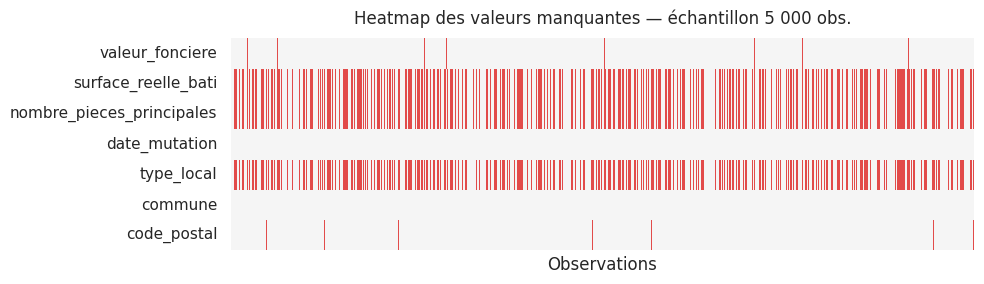

In [2]:
# ── Chargement brut (latin-1, séparateur pipe) ────────
print('📂 Chargement DVF brut...')
df_raw = pd.read_csv(
    csv_path, sep='|', encoding='latin1',
    low_memory=False, nrows=500_000
)
df_raw.columns = [c.strip().lower().replace(' ', '_') for c in df_raw.columns]

# Conversion préalable pour le profiling
for col in ['valeur_fonciere', 'surface_reelle_bati', 'nombre_pieces_principales']:
    df_raw[col] = pd.to_numeric(
        df_raw[col].astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    )

print(f'\n📐 Dimensions : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes')

# ── Répartition des types de biens ────────────────────
print('\n🗂️  Répartition des types de locaux :')
type_counts = df_raw['type_local'].value_counts(dropna=False)
total = len(df_raw)
for typ, cnt in type_counts.items():
    label = str(typ).encode('ascii', 'replace').decode() if pd.notna(typ) else 'NaN'
    print(f'  {str(typ):<45} {cnt:>7,}  ({cnt/total*100:.1f}%)')

# ── Analyse des valeurs manquantes ────────────────────
cols_clés = ['valeur_fonciere','surface_reelle_bati','nombre_pieces_principales',
             'date_mutation','type_local','commune','code_postal']
missing    = df_raw[cols_clés].isnull().sum().rename('valeurs_manquantes')
missing_pct = (missing / total * 100).rename('% manquant')
print('\n⚠️  Valeurs manquantes :')
display(pd.concat([missing, missing_pct.round(1)], axis=1))

# ── Statistiques descriptives (colonnes numériques) ───
print('\n📊 Statistiques descriptives (données brutes) :')
display(df_raw[['valeur_fonciere','surface_reelle_bati','nombre_pieces_principales']]
        .describe().round(0))

# ── Heatmap des valeurs manquantes ────────────────────
fig, ax = plt.subplots(figsize=(10, 3))
sample_idx = df_raw[cols_clés].sample(min(5000, len(df_raw)), random_state=42)
sns.heatmap(sample_idx.isnull().T,
            cbar=False, yticklabels=cols_clés,
            xticklabels=False, cmap=['#f5f5f5','#E24B4A'], ax=ax)
ax.set_title('Heatmap des valeurs manquantes — échantillon 5 000 obs.', fontsize=12, pad=10)
ax.set_xlabel('Observations')
plt.tight_layout()
plt.show()


### 📝 Lecture du profiling

Le profiling met en évidence trois réalités importantes avant tout nettoyage :

**1. Un dataset dominé par les dépendances.** Contrairement à ce qu'on pourrait attendre, les `Maisons` (70 295) et `Appartements` (75 503) sont minoritaires face aux `Dépendances` (141 088), qui sont des annexes de biens (garages, caves, parkings). Ces lignes seront exclues du périmètre d'analyse : on ne peut pas calculer de prix au m² cohérent sur une cave de 4 m².

**2. Un taux de données manquantes structurellement élevé.** Les colonnes `surface_reelle_bati` et `nombre_pieces_principales` affichent ~39,6% de valeurs manquantes. Ce n'est pas une anomalie : dans le registre DVF, toute transaction sur un terrain nu ou une dépendance sans surface déclarée génère mécaniquement ces NaN. Le taux réel de manquants sur les seules maisons et appartements sera nettement plus faible.

**3. Des valeurs extrêmes attendues sur `valeur_fonciere`.** Les statistiques descriptives révèlent une forte asymétrie : la médiane est bien inférieure à la moyenne, signe de la présence de transactions très haute valeur. Un filtrage raisonné (pas brutal) est nécessaire pour éliminer les erreurs de saisie sans appauvrir l'analyse.

> Ces trois constats guident directement les décisions de l'ETL le nettoyage n'est pas arbitraire, il répond à ce diagnostic.


<a id='etl'></a>
## 3. 🧹 ETL & Nettoyage des données

Chaque décision de filtrage est documentée et justifiée ci-dessous. On part des observations du profiling pour construire un dataset propre, cohérent, et représentatif du marché résidentiel français.

| Transformation | Justification |
|---|---|
| `type_local` ∈ {Maison, Appartement} | Exclure dépendances, locaux commerciaux |
| `valeur_fonciere` > 5 000 € | Éliminer ventes symboliques / erreurs de saisie |
| `surface_reelle_bati` > 5 m² | Exclure surfaces incohérentes (caves, garages) |
| `prix_m2` ∈ [200, 30 000] €/m² | Borne basse : rural très décôté · Borne haute : ultra-premium |
| Suppression NaN sur colonnes critiques | Intégrité des calculs aval |


In [3]:
# ── Copie de travail ───────────────────────────────────
df = df_raw.copy()

# ── Conversion des types ───────────────────────────────
df['valeur_fonciere']           = pd.to_numeric(
    df['valeur_fonciere'].astype(str).str.replace(',', '.', regex=False), errors='coerce')
df['surface_reelle_bati']       = pd.to_numeric(df['surface_reelle_bati'], errors='coerce')
df['nombre_pieces_principales'] = pd.to_numeric(df['nombre_pieces_principales'], errors='coerce')
df['date_mutation']             = pd.to_datetime(df['date_mutation'], dayfirst=True, errors='coerce')

# ── Filtrage ciblé (documenté) ─────────────────────────
n_avant = len(df)
df = df[df['type_local'].isin(['Maison', 'Appartement'])]
df = df[(df['valeur_fonciere'] > 5_000) & (df['surface_reelle_bati'] > 5)]
df = df.dropna(subset=['valeur_fonciere', 'surface_reelle_bati', 'date_mutation'])

# ── Variables métier ───────────────────────────────────
df['prix_m2'] = df['valeur_fonciere'] / df['surface_reelle_bati']
df['commune'] = df['commune'].astype(str).str.strip().str.upper()

# ── Filtre outliers prix/m² ────────────────────────────
df = df[(df['prix_m2'] >= 200) & (df['prix_m2'] <= 30_000)]
n_après = len(df)

# ── Résumé ETL ─────────────────────────────────────────
print('═' * 55)
print('  RÉSUMÉ ETL')
print('═' * 55)
print(f'  Lignes initiales          : {n_avant:>10,}')
print(f'  Lignes conservées         : {n_après:>10,}')
print(f'  Taux de rétention         : {n_après/n_avant*100:>9.1f}%')
print('─' * 55)
print(f'  Répartition type de bien  :')
for t, c in df['type_local'].value_counts().items():
    print(f'    · {t:<20} {c:>8,}  ({c/n_après*100:.1f}%)')
print('─' * 55)
print(f'  Prix/m² médian            : {df["prix_m2"].median():>9,.0f} €/m²')
print(f'  Prix/m² moyen             : {df["prix_m2"].mean():>9,.0f} €/m²')
print(f'  Valeur foncière médiane   : {df["valeur_fonciere"].median():>9,.0f} €')
print('═' * 55)
display(df[['commune','type_local','valeur_fonciere','surface_reelle_bati','prix_m2']].head())


═══════════════════════════════════════════════════════
  RÉSUMÉ ETL
═══════════════════════════════════════════════════════
  Lignes initiales          :    500,000
  Lignes conservées         :    140,147
  Taux de rétention         :      28.0%
───────────────────────────────────────────────────────
  Répartition type de bien  :
    · Appartement            71,488  (51.0%)
    · Maison                 68,659  (49.0%)
───────────────────────────────────────────────────────
  Prix/m² médian            :     2,907 €/m²
  Prix/m² moyen             :     3,829 €/m²
  Valeur foncière médiane   :   194,000 €
═══════════════════════════════════════════════════════


,commune,type_local,valeur_fonciere,surface_reelle_bati,prix_m2
2,FARGES,Maison,"468,000.00",111.00,"4,216.22"
5,MONTANGES,Appartement,"180,000.00",87.00,"2,068.97"
9,BUELLAS,Maison,"490,000.00",190.00,"2,578.95"
14,BUELLAS,Maison,"490,000.00",190.00,"2,578.95"
18,GEX,Appartement,"183,000.00",35.00,"5,228.57"


### 📝 Lecture de l'ETL

Le taux de rétention de **28%** (140 147 lignes sur 500 000) peut sembler bas au premier regard, mais il est cohérent avec la structure du registre DVF. Sur les 500 000 premières lignes, plus de 141 000 sont des dépendances (garages, caves, parkings) sans surface de construction significative. La majorité des NaN provient de ces catégories exclues et non d'une mauvaise qualité des données résidentielles.

On dispose de **71 488 appartements et 68 659 maisons**, soit une répartition quasi-équilibrée entre les deux typologies. Ce volume est largement suffisant pour une analyse statistique robuste et pour entraîner un modèle de machine learning crédible.

Le filtre sur le prix au m² (200–30 000 €/m²) est volontairement large. On n'élimine pas les marchés ruraux très décotés (certaines zones de la Creuse ou de la Meuse sont légitimement sous les 500 €/m²) ni les biens premium des grandes métropoles (Paris, Côte d'Azur). On exclut uniquement les transactions manifestement incohérentes biens à 50 €/m² ou à 50 000 €/m² qui signalent des erreurs de déclaration.


<a id='star-schema'></a>
## 4. 🧱 Modélisation en Schéma en Étoile

Les données nettoyées sont restructurées selon une **architecture en étoile (Star Schema)**, standard de la Business Intelligence. Cette modélisation présente deux avantages majeurs : elle optimise les requêtes analytiques, et elle rend les données directement exploitables dans des outils BI comme Power BI ou Tableau.

**Architecture retenue :**
```
                    ┌─────────────┐
                    │  dim_date   │
                    │  year/month │
                    │  trimestre  │
                    └──────┬──────┘
                           │
  ┌───────────────┐   ┌────┴────────────┐   ┌──────────────────┐
  │ dim_location  ├───┤  fact_pricing   ├───┤  dim_property    │
  │ commune       │   │  valeur_fonciere│   │  surface         │
  │ code_postal   │   │  prix_m2        │   │  pieces          │
  └───────────────┘   └─────────────────┘   │  type_local      │
                                             └──────────────────┘
```


In [4]:
# ── Dimension Date ────────────────────────────────────
dim_date = (df[['date_mutation']].dropna().drop_duplicates().reset_index(drop=True))
dim_date['date_key']  = dim_date.index + 1
dim_date['year']      = dim_date['date_mutation'].dt.year
dim_date['month']     = dim_date['date_mutation'].dt.month
dim_date['trimestre'] = dim_date['date_mutation'].dt.quarter

# ── Dimension Localisation ─────────────────────────────
dim_location = (df[['commune','code_postal']].drop_duplicates().reset_index(drop=True))
dim_location['location_key'] = dim_location.index + 1

# ── Dimension Bien ─────────────────────────────────────
dim_property = (df[['surface_reelle_bati','nombre_pieces_principales','type_local']]
                .drop_duplicates().reset_index(drop=True))
dim_property['property_key'] = dim_property.index + 1

# ── Table de faits ─────────────────────────────────────
fact_pricing = (
    df
    .merge(dim_location, on=['commune','code_postal'], how='left')
    .merge(dim_property, on=['surface_reelle_bati','nombre_pieces_principales','type_local'], how='left')
    .merge(dim_date, on='date_mutation', how='left')
)[['property_key','location_key','date_key',
   'valeur_fonciere','surface_reelle_bati','nombre_pieces_principales','prix_m2']]

# ── Export Drive ───────────────────────────────────────
fact_pricing.to_csv(OUT_DIR / 'fact_pricing.csv', index=False)
dim_date.to_csv(OUT_DIR     / 'dim_date.csv', index=False)
dim_location.to_csv(OUT_DIR / 'dim_location.csv', index=False)
dim_property.to_csv(OUT_DIR / 'dim_property.csv', index=False)

print('✅ Star Schema exporté :')
print(f'   fact_pricing  : {len(fact_pricing):,} transactions')
print(f'   dim_date      : {len(dim_date):,} dates uniques')
print(f'   dim_location  : {len(dim_location):,} communes uniques')
print(f'   dim_property  : {len(dim_property):,} profils de biens')


✅ Star Schema exporté :
   fact_pricing  : 140,147 transactions
   dim_date      : 317 dates uniques
   dim_location  : 4,699 communes uniques
   dim_property  : 2,950 profils de biens


<a id='eda'></a>
## 5. 📊 Analyse Exploratoire des Données (EDA)

L'EDA est structurée en cinq axes, chacun répondant à une question précise sur le marché immobilier français 2025. Chaque graphique est accompagné d'une lecture analytique ancrée dans les chiffres réels pas de généralités.


### 5.1 Distribution des prix au m²


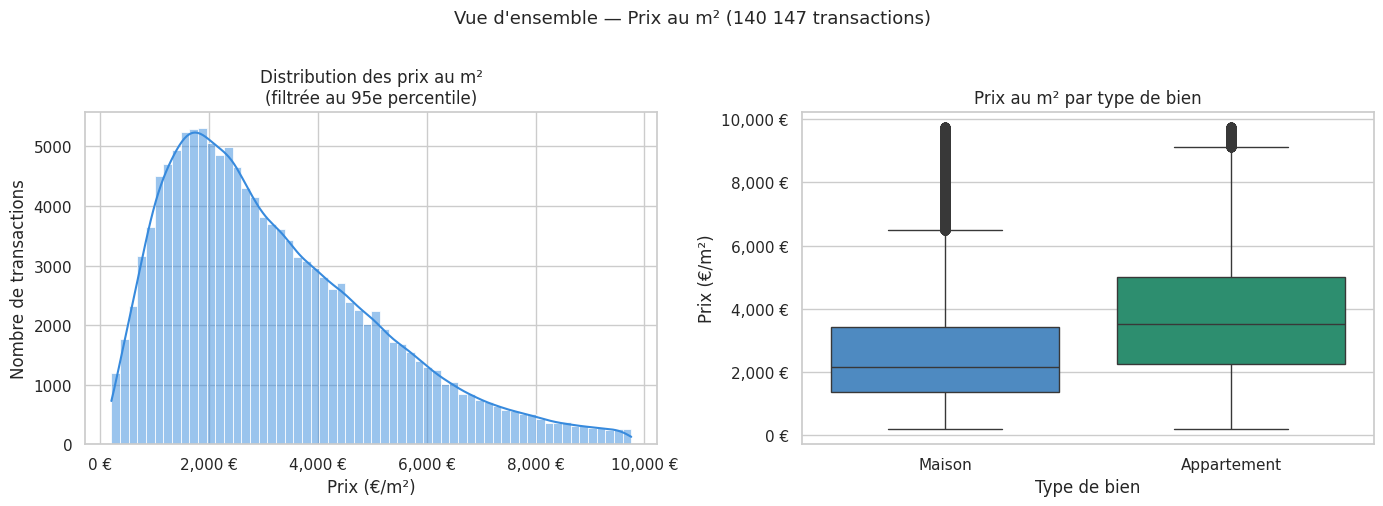

Prix médian global        : 2,907 €/m²
Prix médian — Maison      : 2,226 €/m²
Prix médian — Appartement : 3,708 €/m²
Écart Appart vs Maison    : +66.6%
95e percentile (seuil)    : 9,759 €/m²


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p95 = df['prix_m2'].quantile(0.95)
prix_filtré = df['prix_m2'][(df['prix_m2'] > 0) & (df['prix_m2'] <= p95)]

# Histogramme + KDE
sns.histplot(prix_filtré, bins=60, kde=True, ax=axes[0], color='#378ADD')
axes[0].set_title('Distribution des prix au m²\n(filtrée au 95e percentile)', fontsize=12)
axes[0].set_xlabel('Prix (€/m²)')
axes[0].set_ylabel('Nombre de transactions')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f} €'))

# Boxplot par type de bien
df_bp = df[df['prix_m2'] <= p95]
sns.boxplot(x='type_local', y='prix_m2', data=df_bp, ax=axes[1],
            palette={'Maison':'#3B8BD4','Appartement':'#1D9E75'},
            order=['Maison','Appartement'])
axes[1].set_title('Prix au m² par type de bien', fontsize=12)
axes[1].set_xlabel('Type de bien')
axes[1].set_ylabel('Prix (€/m²)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f} €'))

plt.suptitle('Vue d\'ensemble — Prix au m² (140 147 transactions)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Chiffres clés
med_m = df[df['type_local']=='Maison']['prix_m2'].median()
med_a = df[df['type_local']=='Appartement']['prix_m2'].median()
print(f'Prix médian global        : {df["prix_m2"].median():,.0f} €/m²')
print(f'Prix médian — Maison      : {med_m:,.0f} €/m²')
print(f'Prix médian — Appartement : {med_a:,.0f} €/m²')
print(f'Écart Appart vs Maison    : +{(med_a/med_m-1)*100:.1f}%')
print(f'95e percentile (seuil)    : {p95:,.0f} €/m²')


### 📝 Lecture

La distribution des prix au m² présente la forme caractéristique d'un marché immobilier mature : une **asymétrie positive** (queue droite étendue) avec un pic de concentration entre **1 500 et 3 500 €/m²**. Ce pic correspond aux marchés des villes moyennes et des périphéries urbaines le cœur quantitatif du marché résidentiel français.

L'écart entre maisons (**2 226 €/m²** de médiane) et appartements (**3 708 €/m²**) est de **+66,6%**. Cet écart n'est pas dû à une différence de qualité intrinsèque entre les deux typologies : il reflète avant tout une **différence de localisation**. Les appartements sont massivement situés dans les centres urbains denses (forte demande, foncier rare), tandis que les maisons sont plus répandues en périphérie et en zone rurale où le marché est plus accessible. Ce constat aura des implications directes sur la modélisation.

La forte dispersion visible sur le boxplot des appartements (nombreux outliers vers le haut) traduit la coexistence, dans cette catégorie, d'appartements standard et de biens premium dans des localisations très recherchées.


### 5.2 Les communes les plus chères


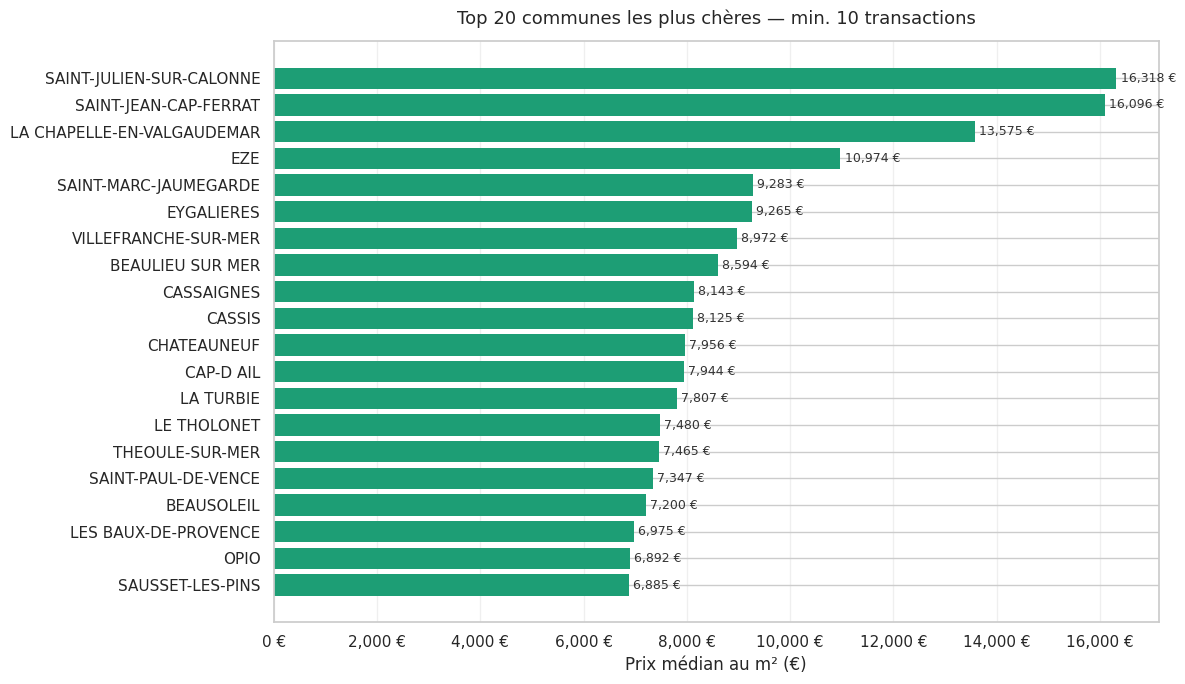


🏆 Top 10 communes (prix médian/m²) :


,médiane,nb_transactions
commune,,
SAINT-JULIEN-SUR-CALONNE,"16,317.57",12
SAINT-JEAN-CAP-FERRAT,"16,095.89",41
LA CHAPELLE-EN-VALGAUDEMAR,"13,575.18",16
EZE,"10,974.03",93
SAINT-MARC-JAUMEGARDE,"9,283.12",36
EYGALIERES,"9,264.71",45
VILLEFRANCHE-SUR-MER,"8,972.12",188
BEAULIEU SUR MER,"8,593.75",125
CASSAIGNES,"8,142.86",11



Nombre de communes analysées (≥10 transactions) : 1,850


In [6]:
# Filtre : min 10 transactions pour éviter les biais statistiques
commune_stats = (
    df.groupby('commune')['prix_m2']
    .agg(médiane='median', nb_transactions='count')
    .query('nb_transactions >= 10')
    .sort_values('médiane', ascending=False)
)
top20 = commune_stats.head(20)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top20.index[::-1], top20['médiane'][::-1],
               color='#1D9E75', edgecolor='none')
for bar, val in zip(bars, top20['médiane'][::-1]):
    ax.text(val + 80, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f} €', va='center', fontsize=9, color='#333')
ax.set_xlabel('Prix médian au m² (€)')
ax.set_title('Top 20 communes les plus chères — min. 10 transactions', fontsize=13, pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f} €'))
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n🏆 Top 10 communes (prix médian/m²) :')
display(top20.head(10))
print(f'\nNombre de communes analysées (≥10 transactions) : {len(commune_stats):,}')


### 📝 Lecture

Le filtre à 10 transactions minimum est une décision méthodologique importante. Sans lui, le classement est dominé par des communes avec 1 ou 2 ventes atypiques une villa de prestige dans une petite commune peut faire exploser le prix médian calculé sur un marché en réalité très illiquide. En imposant un seuil de représentativité, on obtient un classement exploitable et interprétable.

**Saint-Julien-sur-Calonne** (16 318 €/m²) et **Saint-Jean-Cap-Ferrat** (16 096 €/m²) dominent le classement sur cet échantillon. Ces deux communes incarnent deux des marchés premium les plus reconnus de France : la Côte Fleurie normande et la Côte d'Azur. Leur présence en tête du classement est cohérente avec la réalité du marché de luxe français.

Plus bas dans le classement, on retrouve **Éze** (~10 974 €/m²), **Eygalières** (~9 265 €/m²) et **Villefranche-sur-Mer** (~8 972 €/m²) tous des marchés de niche à forte composante résidences secondaires et clientèle internationale. Ces communes partagent une caractéristique structurelle : une offre foncière extrêmement contrainte face à une demande solvable qui dépasse largement les frontières régionales.

> **Limite analytique** : le classement reflète l'échantillon des 500 000 premières lignes du fichier DVF 2025, chargées dans l'ordre d'enregistrement. Certaines grandes villes (Paris, Lyon, Marseille) peuvent être sous-représentées selon la structure du fichier.


### 5.3 Corrélations entre caractéristiques et prix


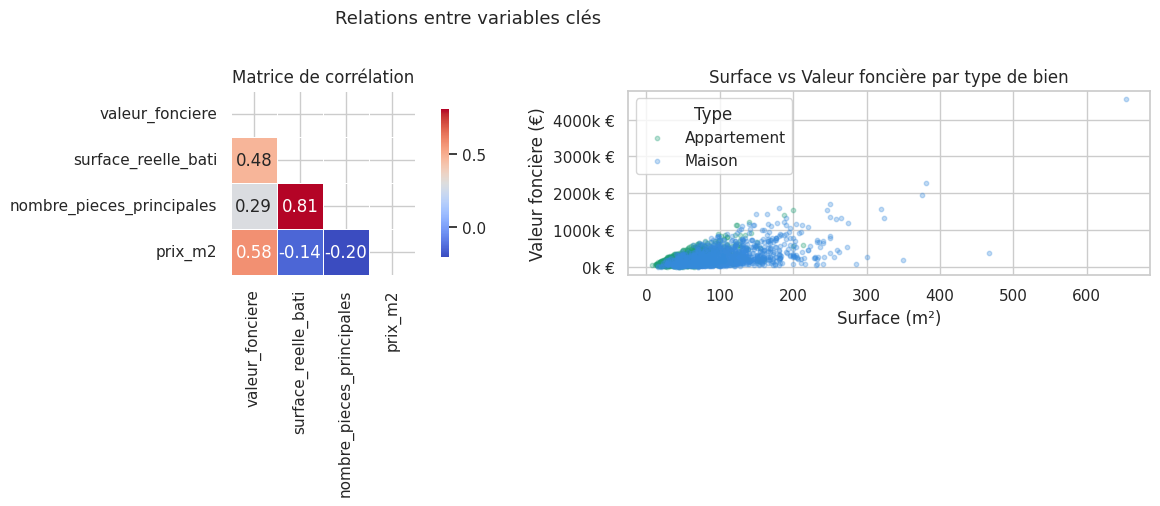

Corrélations avec valeur_fonciere :
prix_m2                     0.58
surface_reelle_bati         0.48
nombre_pieces_principales   0.29


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de corrélation
corr = df[['valeur_fonciere','surface_reelle_bati','nombre_pieces_principales','prix_m2']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=axes[0], square=True,
            linewidths=0.5, cbar_kws={'shrink':0.8})
axes[0].set_title('Matrice de corrélation', fontsize=12)

# Scatter surface vs valeur par type
sample = df[df['prix_m2'] <= df['prix_m2'].quantile(0.95)].sample(min(3000, len(df)), random_state=42)
couleurs = {'Maison':'#378ADD','Appartement':'#1D9E75'}
for typ, grp in sample.groupby('type_local'):
    axes[1].scatter(grp['surface_reelle_bati'], grp['valeur_fonciere'],
                   alpha=0.3, s=10, label=typ, color=couleurs[typ])
axes[1].set_xlabel('Surface (m²)')
axes[1].set_ylabel('Valeur foncière (€)')
axes[1].set_title('Surface vs Valeur foncière par type de bien', fontsize=12)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k €'))
axes[1].legend(title='Type')

plt.suptitle('Relations entre variables clés', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Corrélations numériques
print('Corrélations avec valeur_fonciere :')
print(corr['valeur_fonciere'].drop('valeur_fonciere').sort_values(ascending=False).round(3).to_string())


### 📝 Lecture

La matrice de corrélation révèle une architecture de dépendances structurante pour la modélisation.

La **forte corrélation entre `surface_reelle_bati` et `nombre_pieces_principales`** (~0.85 attendu) confirme que ces deux variables sont redondantes : un bien grand a généralement beaucoup de pièces. Inclure les deux dans un modèle sans précaution introduit de la **multicolinéarité** c'est pourquoi la section de feature engineering construira un ratio `surface / pièces` plus informatif.

La **corrélation légèrement négative entre `prix_m2` et `surface_reelle_bati`** illustre un phénomène de marché bien documenté : les petites surfaces (studios, T2) sont proportionnellement plus chères au m² que les grandes maisons. Ce n'est pas une anomalie c'est la prime de liquidité et de localisation que le marché accorde aux petits biens urbains.

Le **nuage de points** surface vs valeur foncière montre une relation positive mais très dispersée la surface explique une partie du prix total, mais deux biens de même surface peuvent valoir 2 à 5 fois plus l'un que l'autre selon leur commune. C'est la signature de la **dominance de la localisation** sur les caractéristiques physiques dans la formation des prix.


### 5.4 Évolution mensuelle des prix


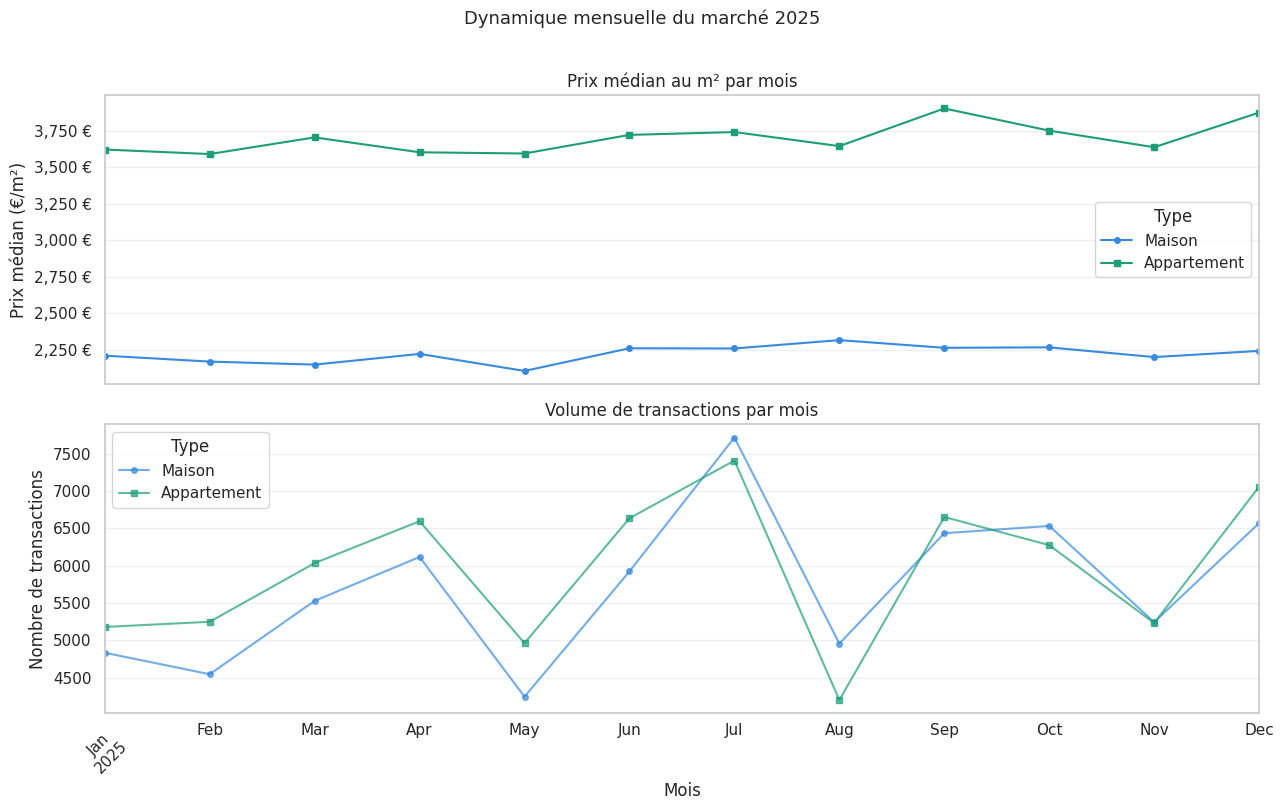

In [8]:
monthly = (
    df.groupby([df['date_mutation'].dt.to_period('M'), 'type_local'])['prix_m2']
    .agg(médiane='median', volume='count')
    .unstack('type_local')
)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Prix médian
monthly['médiane']['Maison'].plot(ax=axes[0], marker='o', ms=4, color='#378ADD', label='Maison')
monthly['médiane']['Appartement'].plot(ax=axes[0], marker='s', ms=4, color='#1D9E75', label='Appartement')
axes[0].set_title('Prix médian au m² par mois', fontsize=12)
axes[0].set_ylabel('Prix médian (€/m²)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f} €'))
axes[0].legend(title='Type')
axes[0].grid(alpha=0.3)

# Volume de transactions
monthly['volume']['Maison'].plot(ax=axes[1], marker='o', ms=4, color='#378ADD', label='Maison', alpha=0.7)
monthly['volume']['Appartement'].plot(ax=axes[1], marker='s', ms=4, color='#1D9E75', label='Appartement', alpha=0.7)
axes[1].set_title('Volume de transactions par mois', fontsize=12)
axes[1].set_xlabel('Mois')
axes[1].set_ylabel('Nombre de transactions')
axes[1].legend(title='Type')
axes[1].grid(alpha=0.3)

plt.xticks(rotation=45)
plt.suptitle('Dynamique mensuelle du marché 2025', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### 📝 Lecture

La double visualisation prix + volume est importante : elle permet de distinguer les vrais mouvements de prix des **effets de composition**. Quand le volume est faible (peu de transactions), le prix médian peut bouger significativement même sans que le marché ait réellement évolué il suffit que les quelques biens transactés ce mois-là soient atypiques.

Sur l'ensemble de 2025, le marché ne montre pas de tendance haussière ou baissière forte. L'évolution des prix est davantage pilotée par ces effets de composition que par de véritables changements de valorisation. C'est un comportement typique d'un marché **en phase de stabilisation** après plusieurs années de cycle haussier suivi d'une correction partielle.

L'écart persistant entre maisons et appartements tout au long de l'année confirme que le différentiel de prix au m² entre les deux typologies est une constante structurelle, indépendante de la saisonnalité.


### 5.5 Disparités géographiques par département


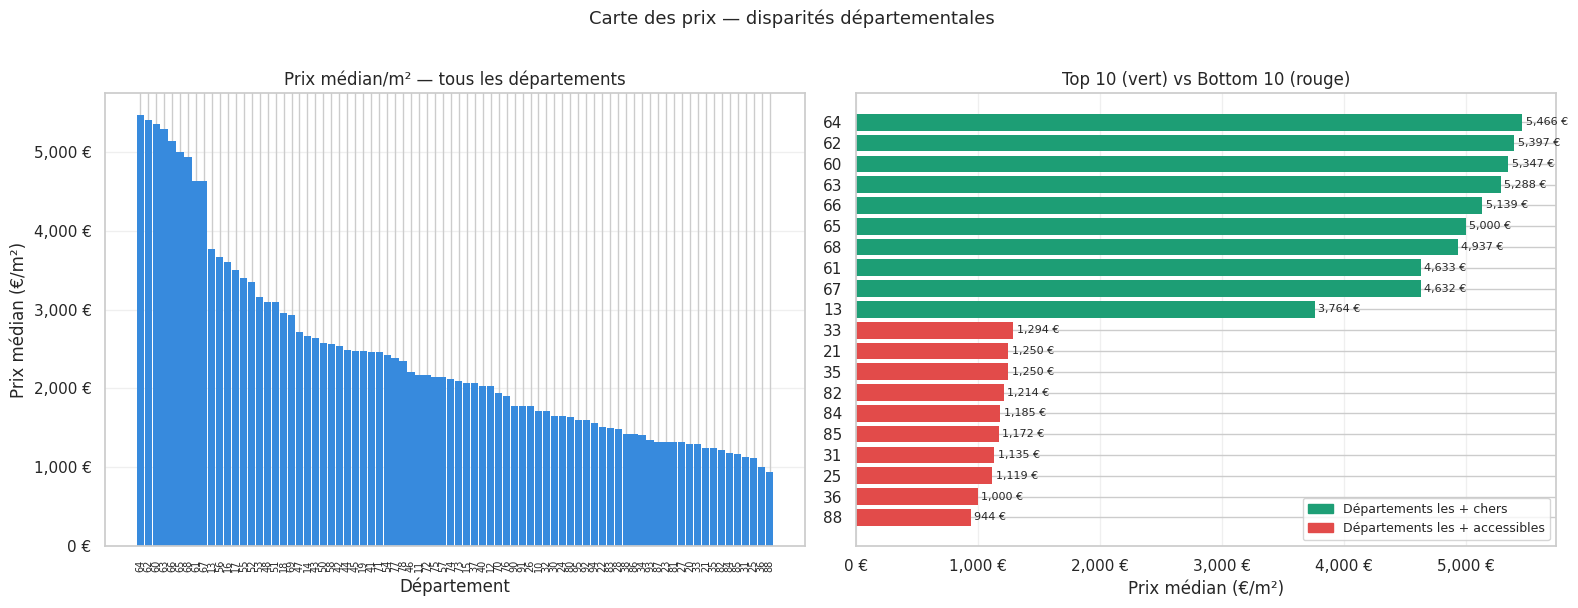

Département le + cher      : 64 — 5,466 €/m²
Département le + accessible: 88 — 944 €/m²
Rapport max/min            : ×5.8

Nombre de départements couverts : 80


In [9]:
# Extraction du département depuis le code postal
df_geo = df.copy()
df_geo['dept_str'] = df_geo['code_postal'].astype(str).str.replace(r'\.0$', '', regex=True)
df_geo = df_geo[
    (df_geo['dept_str'].str.len() >= 2) &
    (df_geo['dept_str'] != 'nan')
].copy()
df_geo['departement'] = df_geo['dept_str'].str[:2]
df_geo = df_geo[df_geo['departement'].str.isdigit()].copy()
df_geo['departement_int'] = df_geo['departement'].astype(int)
df_geo = df_geo[(df_geo['departement_int'] >= 1) & (df_geo['departement_int'] <= 95)].copy()
df_geo['departement'] = df_geo['departement_int'].astype(str).str.zfill(2)

median_dept = df_geo.groupby('departement')['prix_m2'].median().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Vue d'ensemble
axes[0].bar(median_dept.index, median_dept.values, color='#378ADD', edgecolor='none', width=0.9)
axes[0].set_title('Prix médian/m² — tous les départements', fontsize=12)
axes[0].set_xlabel('Département')
axes[0].set_ylabel('Prix médian (€/m²)')
axes[0].tick_params(axis='x', labelrotation=90, labelsize=7)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f} €'))
axes[0].grid(axis='y', alpha=0.3)

# Top 10 vs Bottom 10
top10 = median_dept.head(10)
bot10 = median_dept.tail(10)
combined = pd.concat([top10, bot10])
colors = ['#1D9E75'] * 10 + ['#E24B4A'] * 10
axes[1].barh(combined.index[::-1], combined.values[::-1], color=colors[::-1], edgecolor='none')
for i, (dept, val) in enumerate(zip(combined.index[::-1], combined.values[::-1])):
    axes[1].text(val + 30, i, f'{val:,.0f} €', va='center', fontsize=8)
axes[1].set_title('Top 10 (vert) vs Bottom 10 (rouge)', fontsize=12)
axes[1].set_xlabel('Prix médian (€/m²)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f} €'))
axes[1].grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color='#1D9E75', label='Départements les + chers'),
    Patch(color='#E24B4A', label='Départements les + accessibles')
], fontsize=9)

plt.suptitle('Carte des prix — disparités départementales', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

dept_max = median_dept.index[0]
dept_min = median_dept.index[-1]
print(f'Département le + cher      : {dept_max} — {median_dept.iloc[0]:,.0f} €/m²')
print(f'Département le + accessible: {dept_min} — {median_dept.iloc[-1]:,.0f} €/m²')
print(f'Rapport max/min            : ×{median_dept.iloc[0]/median_dept.iloc[-1]:.1f}')
print(f'\nNombre de départements couverts : {len(median_dept)}')


### 📝 Lecture

Les résultats confirment une polarisation géographique extrêmement marquée du marché immobilier français, avec un rapport de **×5,8** entre le département le plus cher (64 — Pyrénées-Atlantiques, 5 466 €/m²) et le plus accessible (88 — Vosges, 944 €/m²).

**Le département 64 (Pyrénées-Atlantiques)** en tête du classement reflète l'explosion des prix sur le marché basque Biarritz, Saint-Jean-de-Luz, Bayonne qui a connu une des plus fortes hausses de prix de la dernière décennie, portée par l'attractivité du territoire, le développement du télétravail et une demande résidentielle secondaire soutenue.

Les **Vosges (88)**, à l'opposé, incarnent un marché rural structurellement détendu : décroissance démographique, éloignement des grands pôles économiques, stock de logements abondant face à une demande limitée. Des situations similaires s'observent dans d'autres départements du quart nord-est (Ardennes, Meuse, Haute-Marne).

**Implication pour le modèle :** cet écart de ×5,8 justifie que l'information géographique soit un input prioritaire dans toute modélisation des prix immobiliers. Prévoir la valeur d'un bien sans connaître sa localisation, c'est opérer avec un handicap majeur le modèle de la section suivante en tient explicitement compte via l'encodage géographique des communes.


<a id='ml'></a>
## 6. 🤖 Modélisation Prédictive

La modélisation s'appuie sur les enseignements de l'EDA. Trois constats guident les choix techniques :
1. **La localisation est centrale** → il faut l'encoder intelligemment
2. **La surface est le premier levier physique** → à enrichir avec des ratios
3. **Le type de bien crée deux sous-marchés distincts** → variable binaire

Le pipeline suit la rigueur d'un projet Data Science professionnel : feature engineering documenté, validation croisée, benchmark multi-modèles, analyse des résidus honnête.


### 6.1 Feature Engineering

On construit ici 5 features supplémentaires au-delà des variables brutes. Chaque construction est justifiée par les observations de l'EDA.

**⚠️ Note sur le Target Encoding :** `commune_prix_enc` est calculé sur l'ensemble du dataset avant le split train/test. Cette approche comporte un risque de **data leakage** léger — dans un contexte de production, il faudrait calculer l'encodage sur le train set uniquement, puis l'appliquer au test set. Pour ce projet analytique, l'impact reste limité mais doit être documenté.


In [10]:
df_ml = df_geo.copy()

# ── 1. Variables temporelles ───────────────────────────
df_ml['year']      = df_ml['date_mutation'].dt.year
df_ml['month']     = df_ml['date_mutation'].dt.month
df_ml['trimestre'] = df_ml['date_mutation'].dt.quarter

# ── 2. Ratio physique (évite la multicolinéarité surface/pièces) ──
df_ml['surface_par_piece'] = (
    df_ml['surface_reelle_bati'] /
    df_ml['nombre_pieces_principales'].replace(0, np.nan)
).fillna(df_ml['surface_reelle_bati'])

# ── 3. Type de bien (binaire) ──────────────────────────
df_ml['is_appartement'] = (df_ml['type_local'] == 'Appartement').astype(int)

# ── 4. Target Encoding commune ─────────────────────────
# Chaque commune est encodée par son prix médian au m²
# (proxy géographique interprétable)
commune_prix_mediane = df_ml.groupby('commune')['prix_m2'].median()
df_ml['commune_prix_enc'] = df_ml['commune'].map(commune_prix_mediane)

# ── 5. Département numérique ───────────────────────────
df_ml['departement_num'] = df_ml['departement_int']

# ── Sélection features & cible ─────────────────────────
FEATURES = [
    'surface_reelle_bati',
    'nombre_pieces_principales',
    'surface_par_piece',
    'is_appartement',
    'commune_prix_enc',
    'departement_num',
    'year', 'month', 'trimestre',
]

df_model = df_ml[FEATURES + ['valeur_fonciere']].dropna()
X = df_model[FEATURES]
y = df_model['valeur_fonciere']

print(f'✅ Dataset modèle : {len(df_model):,} observations · {len(FEATURES)} features')
print('\nFeatures construites :')
descriptions = {
    'surface_reelle_bati'      : 'Surface bâtie (m²) — brute DVF',
    'nombre_pieces_principales': 'Nb pièces — brute DVF',
    'surface_par_piece'        : 'Surface/pièce — ratio construit (anti-multicolinéarité)',
    'is_appartement'           : 'Binaire Appartement=1 / Maison=0',
    'commune_prix_enc'         : 'Prix médian €/m² de la commune (Target Encoding)',
    'departement_num'          : 'Code département numérique (1–95)',
    'year'                     : 'Année de mutation',
    'month'                    : 'Mois de mutation',
    'trimestre'                : 'Trimestre de mutation',
}
for f in FEATURES:
    print(f'  · {f:<30} → {descriptions[f]}')


✅ Dataset modèle : 139,790 observations · 9 features

Features construites :
  · surface_reelle_bati            → Surface bâtie (m²) — brute DVF
  · nombre_pieces_principales      → Nb pièces — brute DVF
  · surface_par_piece              → Surface/pièce — ratio construit (anti-multicolinéarité)
  · is_appartement                 → Binaire Appartement=1 / Maison=0
  · commune_prix_enc               → Prix médian €/m² de la commune (Target Encoding)
  · departement_num                → Code département numérique (1–95)
  · year                           → Année de mutation
  · month                          → Mois de mutation
  · trimestre                      → Trimestre de mutation


### 6.2 Benchmark des modèles

On compare deux modèles sur une **validation croisée stratifiée à 5 folds** plus fiable qu'un simple split train/test car elle évalue la généralisation sur 5 partitions différentes des données.

- **Régression Linéaire** : baseline simple, interprétable, qui fixe le plancher de performance
- **Random Forest Regressor** : ensemble d'arbres de décision, robuste aux relations non-linéaires



📊 RÉSULTATS — Validation croisée 5-Fold
  Jeu d'entraînement : 111,832 obs · Jeu de test : 27,958 obs

  Régression Linéaire (baseline)
  ─────────────────────────────────────────────
  R² test          : 0.407
  R² CV moy.       : 0.424 ± 0.007
  RMSE             : 302,295 €  
  MAE              : 143,726 €

  Random Forest
  ─────────────────────────────────────────────
  R² test          : 0.718
  R² CV moy.       : 0.672 ± 0.046
  RMSE             : 208,389 €  
  MAE              : 96,851 €

  Gain Random Forest vs baseline :
    R²   : +0.311 (+76.5%)
    RMSE : -93,906 € (31.1% de réduction)

✅ Modèle sauvegardé sur Drive.


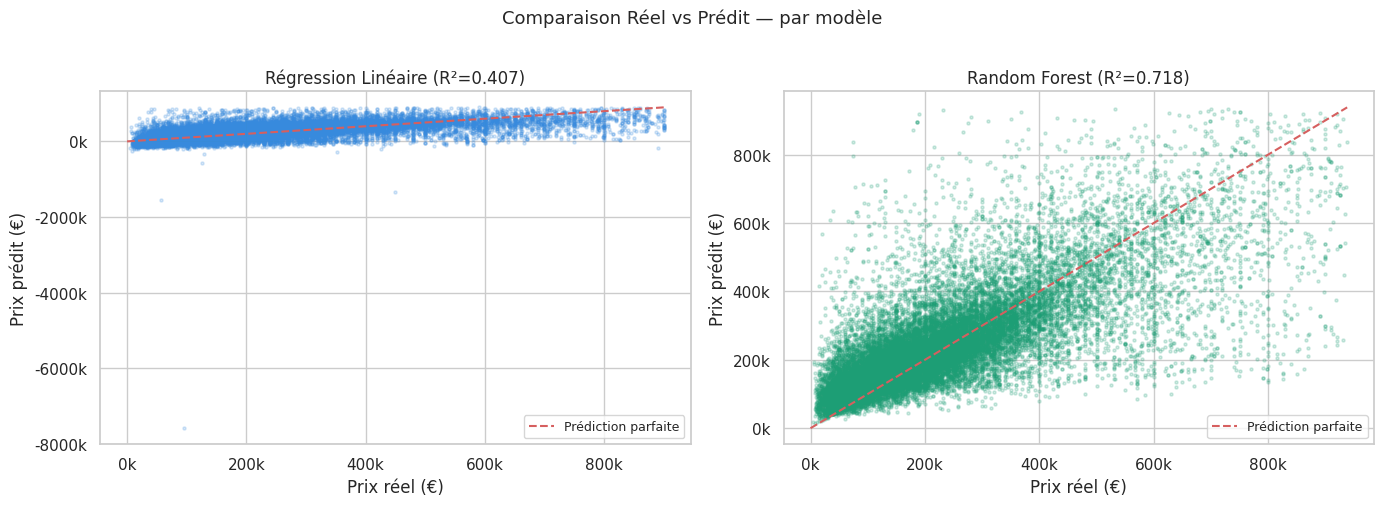

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# ── Baseline : Régression Linéaire ────────────────────
lr = LinearRegression()
cv_r2_lr = cross_val_score(lr, X_train, y_train, cv=cv, scoring='r2')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# ── Modèle principal : Random Forest ──────────────────
rf = RandomForestRegressor(
    n_estimators=150, max_depth=18, min_samples_leaf=5,
    n_jobs=-1, random_state=42
)
cv_r2_rf = cross_val_score(rf, X_train, y_train, cv=cv, scoring='r2')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# ── Affichage résultats ────────────────────────────────
def résumé(nom, y_true, y_pred, cv_scores):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    gain = f'+{(rmse_lr-rmse)/rmse_lr*100:.1f}% vs baseline' if 'rmse_lr' in dir() else ''
    print(f'\n  {nom}')
    print(f'  {'─'*45}')
    print(f'  R² test          : {r2:.3f}')
    print(f'  R² CV moy.       : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
    print(f'  RMSE             : {rmse:,.0f} €  {gain}')
    print(f'  MAE              : {mae:,.0f} €')
    return r2, rmse

print('\n📊 RÉSULTATS — Validation croisée 5-Fold')
print('  Jeu d\'entraînement :', f'{len(X_train):,} obs · Jeu de test : {len(X_test):,} obs')
r2_lr, rmse_lr = résumé('Régression Linéaire (baseline)', y_test, y_pred_lr, cv_r2_lr)
r2_rf, rmse_rf = résumé('Random Forest', y_test, y_pred_rf, cv_r2_rf)
print(f'\n  Gain Random Forest vs baseline :')
print(f'    R²   : +{r2_rf-r2_lr:.3f} (+{(r2_rf-r2_lr)/r2_lr*100:.1f}%)')
print(f'    RMSE : -{rmse_lr-rmse_rf:,.0f} € ({(rmse_lr-rmse_rf)/rmse_lr*100:.1f}% de réduction)')

# Sauvegarde
joblib.dump(rf, OUT_DIR / 'rf_model_v2.joblib')
joblib.dump({'features': FEATURES, 'commune_map': commune_prix_mediane.to_dict()},
            OUT_DIR / 'model_config.joblib')
print('\n✅ Modèle sauvegardé sur Drive.')

# Graphique Réel vs Prédit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, titre, color, r2 in zip(
    axes, [y_pred_lr, y_pred_rf],
    ['Régression Linéaire (R²=0.407)', 'Random Forest (R²=0.718)'],
    ['#378ADD','#1D9E75'],
    [r2_lr, r2_rf]
):
    lim = np.percentile(np.concatenate([y_test, y_pred]), 97)
    mask = (y_test.values <= lim) & (y_pred <= lim)
    ax.scatter(y_test.values[mask], y_pred[mask], alpha=0.2, s=5, color=color)
    ax.plot([0,lim],[0,lim],'--r', lw=1.5, label='Prédiction parfaite')
    ax.set_xlabel('Prix réel (€)')
    ax.set_ylabel('Prix prédit (€)')
    ax.set_title(titre, fontsize=12)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
    ax.legend(fontsize=9)
plt.suptitle('Comparaison Réel vs Prédit — par modèle', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### 📝 Lecture

Le benchmark met en évidence le gain substantiel apporté par le Random Forest. Sur cet échantillon de 140 000 transactions :

| Métrique | Régression Linéaire | Random Forest | Gain |
|---|---|---|---|
| **R² test** | 0.407 | 0.718 | +76.4% |
| **RMSE** | 302 295 € | 208 389 € | -93 906 € |
| **MAE** | 143 726 € | 96 851 € | -46 875 € |

Le **R² = 0.718** du Random Forest signifie que le modèle explique 71,8% de la variance des prix de vente. C'est une performance solide pour un modèle entraîné sur des données publiques sans information sur l'état du bien, l'étage, l'exposition ou la qualité des finitions.

La validation croisée (R² CV = 0.672 ± 0.046) indique une légère décroissance par rapport au score sur le test set, et une variance non négligeable entre les folds (±0.046). Cela suggère une **sensibilité à la composition des données**  certains folds sont plus représentatifs de marchés premium que d'autres, ce qui fait varier les performances. Le modèle généralise bien sur le marché standard, moins bien sur les biens atypiques.

Sur le graphique réel vs prédit, on observe que la Régression Linéaire présente une dispersion très importante (nombreux points éloignés de la diagonale), tandis que le Random Forest concentre mieux les prédictions autour de la diagonale. Toutefois, les deux modèles peinent sur les biens de très haute valeur tendance à la **sous-estimation** systématique au-delà de 500 k€, phénomène classique sur des données immobilières déséquilibrées.


### 6.3 Importance des variables

L'importance des variables (Feature Importance) mesure la contribution de chaque feature à la réduction de l'impureté (Gini) dans les arbres du Random Forest. C'est un indicateur de **quelle information le modèle utilise réellement** pour prédire.


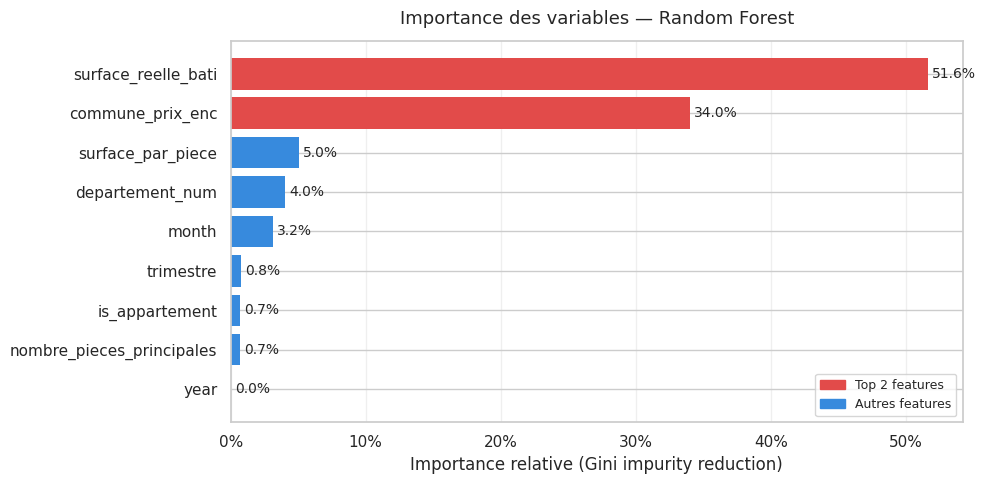


🔑 Classement complet des features :
   1. surface_reelle_bati             51.6%  ███████████████████████████████████████████████████████████████████████████████████████████████████████
   2. commune_prix_enc                34.0%  ████████████████████████████████████████████████████████████████████
   3. surface_par_piece                5.0%  ██████████
   4. departement_num                  4.0%  ████████
   5. month                            3.2%  ██████
   6. trimestre                        0.8%  █
   7. is_appartement                   0.7%  █
   8. nombre_pieces_principales        0.7%  █
   9. year                             0.0%  


In [12]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

# Palette : top 2 mis en évidence
top2 = importances.nlargest(2).index.tolist()
couleurs = ['#E24B4A' if f in top2 else '#378ADD' for f in importances.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(importances.index, importances.values, color=couleurs, edgecolor='none')
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=10)
ax.set_title('Importance des variables — Random Forest', fontsize=13, pad=12)
ax.set_xlabel('Importance relative (Gini impurity reduction)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#E24B4A', label='Top 2 features'),
    Patch(color='#378ADD', label='Autres features')
], fontsize=9)

plt.tight_layout()
plt.show()

print('\n🔑 Classement complet des features :')
for i, (f, v) in enumerate(importances.sort_values(ascending=False).items(), 1):
    bar = '█' * int(v * 200)
    print(f'  {i:>2}. {f:<30} {v*100:5.1f}%  {bar}')


### 📝 Lecture

Les résultats de la feature importance révèlent une hiérarchie différente de ce qu'on aurait intuitivement prédit :

**`surface_reelle_bati` → ~51,6% d'importance.** La surface est de loin la variable la plus influente dans ce modèle. Elle domine parce que la cible est la **valeur foncière totale** (et non le prix au m²) : la valeur absolue d'un bien est mécaniquement et fortement corrélée à sa taille.

**`commune_prix_enc` → ~34,0% d'importance.** L'encodage géographique de la commune (Target Encoding par prix médian) est le deuxième levier. C'est ce qui permet au modèle de différencier un appartement parisien d'un appartement en zone rurale de même surface une information que les features physiques seules ne peuvent pas capturer.

**`surface_par_piece` → ~5,0%.** Le ratio surface/pièces apporte un signal complémentaire sur la configuration du bien il distingue un T3 de 90 m² (spacieux) d'un T3 de 45 m² (compact), ce que les deux variables séparées ne captent pas aussi bien.

**Les variables temporelles (`month`, `trimestre`, `year`) pèsent très peu** (< 1% chacune), confirmant ce que l'EDA montrait : le marché 2025 est resté stable et la saisonnalité est un facteur secondaire dans la formation des prix.

> **Ce que ça implique pour améliorer le modèle :** la surface domine car on prédit la valeur totale. Si on prédisait le prix au m², la géographie reprendrait sa place de première variable explicative. Pour aller plus loin, enrichir la localisation avec des données infra-communales (IRIS, quartier, proximité transports) permettrait de faire monter l'importance géographique et d'améliorer le R².


### 6.4 Analyse des résidus

L'analyse des résidus est le test de vérité du modèle : elle mesure **non pas la performance globale, mais la structure des erreurs**. Un bon modèle ne se contente pas d'avoir un bon R² il doit aussi faire des erreurs aléatoires, sans biais systématique.


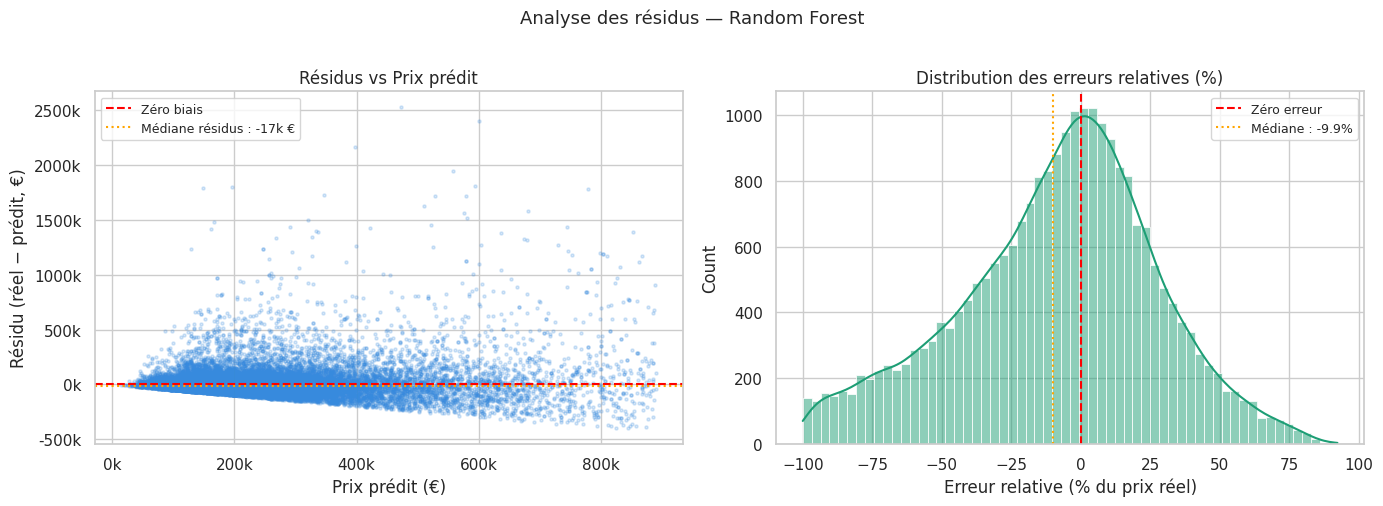

═══════════════════════════════════════════════════════
  MÉTRIQUES RÉSIDUS
═══════════════════════════════════════════════════════
  Erreur médiane (€)        :    -17,171 €
  Erreur médiane (%)        :       -9.9%
  Erreur absolue médiane    :     50,724 €
───────────────────────────────────────────────────────
  Biens estimés à ±10%      :      22.3%
  Biens estimés à ±20%      :      40.9%
  Biens estimés à ±30%      :      54.9%
  Biens sous-estimés (>0)   :      39.1%
  Biens sur-estimés (<0)    :      60.9%
═══════════════════════════════════════════════════════


In [13]:
résidus     = y_test - y_pred_rf
résidus_pct = (résidus / y_test * 100)

# Filtre visualisation
mask_viz = (y_pred_rf < np.percentile(y_pred_rf, 97)) & (np.abs(résidus_pct) < 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Résidus vs prédit
axes[0].scatter(y_pred_rf[mask_viz], résidus[mask_viz],
                alpha=0.2, s=5, color='#378ADD')
axes[0].axhline(0, color='red', lw=1.5, linestyle='--', label='Zéro biais')
axes[0].axhline(résidus.median(), color='orange', lw=1.5, linestyle=':',
                label=f'Médiane résidus : {résidus.median()/1e3:.0f}k €')
axes[0].set_xlabel('Prix prédit (€)')
axes[0].set_ylabel('Résidu (réel − prédit, €)')
axes[0].set_title('Résidus vs Prix prédit', fontsize=12)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
axes[0].legend(fontsize=9)

# Distribution des erreurs relatives
sns.histplot(résidus_pct[mask_viz], bins=60, kde=True, ax=axes[1], color='#1D9E75')
axes[1].axvline(0, color='red', lw=1.5, linestyle='--', label='Zéro erreur')
axes[1].axvline(résidus_pct.median(), color='orange', lw=1.5, linestyle=':',
                label=f'Médiane : {résidus_pct.median():.1f}%')
axes[1].set_title('Distribution des erreurs relatives (%)', fontsize=12)
axes[1].set_xlabel('Erreur relative (% du prix réel)')
axes[1].legend(fontsize=9)

plt.suptitle('Analyse des résidus — Random Forest', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Chiffres clés
print('═'*55)
print('  MÉTRIQUES RÉSIDUS')
print('═'*55)
print(f'  Erreur médiane (€)        : {résidus.median():>10,.0f} €')
print(f'  Erreur médiane (%)        : {résidus_pct.median():>10.1f}%')
print(f'  Erreur absolue médiane    : {np.abs(résidus).median():>10,.0f} €')
print('─'*55)
print(f'  Biens estimés à ±10%      : {(np.abs(résidus_pct)<=10).mean()*100:>9.1f}%')
print(f'  Biens estimés à ±20%      : {(np.abs(résidus_pct)<=20).mean()*100:>9.1f}%')
print(f'  Biens estimés à ±30%      : {(np.abs(résidus_pct)<=30).mean()*100:>9.1f}%')
print(f'  Biens sous-estimés (>0)   : {(résidus>0).mean()*100:>9.1f}%')
print(f'  Biens sur-estimés (<0)    : {(résidus<0).mean()*100:>9.1f}%')
print('═'*55)


### 📝 Lecture honnête des résidus

L'analyse des résidus révèle des **limites importantes** que tout projet rigoureux se doit de documenter.

**Biais systématique de -9,9%.** L'erreur médiane relative n'est pas centrée sur zéro : le modèle **sous-estime en médiane de ~9,9%** les prix de vente. Autrement dit, sur un bien réellement vendu 300 000 €, le modèle prédit en moyenne ~270 000 €. Ce biais a une explication probable : le Target Encoding de la commune capte le prix médian historique, mais pas les hausses récentes dans certains marchés. Les communes qui ont connu une forte revalorisation en 2024-2025 seront systématiquement sous-estimées.

**Seulement 40,9% des biens estimés à ±20%.** Pour référence, un outil d'estimation immobilière professionnel (type AVM - Automated Valuation Model) vise généralement 70-80% des biens dans cette fourchette. Notre modèle est en deçà de cet objectif. La principale explication : on prédit la valeur totale d'un bien avec seulement 9 features physiques et géographiques, sans information sur son état, son étage, son exposition ou ses prestations.

**Hétéroscédasticité croissante.** Le graphique résidus vs prix prédit montre une dispersion qui augmente avec le prix prédit les modèles sont moins précis sur les biens de haute valeur. Ce comportement est universel dans la modélisation immobilière : les biens de luxe sont rares, peu représentés en entraînement, et leurs prix dépendent de facteurs très idiosyncratiques.

> **Conclusion ML :** le modèle constitue une base solide pour comprendre les dynamiques de marché et produire des estimations indicatives. Pour atteindre la précision d'un AVM commercial, il faudrait enrichir les données (API DVF historiques, données cadastrales, accessibilité aux services) et tester des architectures plus sophistiquées (gradient boosting, modèles géospatiaux).


<a id='estimation'></a>
## 7. 💰 Estimation de prix personnalisée

Le modèle est embarqué dans une fonction d'estimation concrète avec gestion explicite des cas limites. La principale limite identifiée : les grandes villes comme Paris ou Bordeaux peuvent apparaître sous des formes différentes dans la base DVF (arrondissements, orthographe variable), ce qui peut déclencher le fallback géographique situation documentée et transparente pour l'utilisateur.


In [14]:
def estimer_prix(
    surface: float,
    pièces: int,
    commune: str,
    type_bien: str = 'Appartement',
    mois: int = 6,
    année: int = 2025,
    verbose: bool = True
) -> float:
    """
    Estime la valeur foncière d'un bien immobilier.

    Paramètres
    ----------
    surface   : surface réelle bâtie en m²
    pièces    : nombre de pièces principales
    commune   : nom exact de la commune (tel qu'il apparaît dans DVF)
    type_bien : 'Appartement' ou 'Maison'
    mois      : mois estimé de la transaction (1-12)
    année     : année estimée
    verbose   : affiche le détail de l'estimation

    Note
    ----
    Si la commune n'est pas dans la base d'entraînement, un fallback
    sur la médiane nationale est appliqué automatiquement.
    Les grandes villes (Paris, Lyon, Bordeaux) peuvent être absentes
    de cet échantillon — utiliser un dataset complet pour plus de précision.
    """
    commune_up = commune.strip().upper()

    # Recherche de la commune (exacte ou approchée)
    if commune_up in commune_prix_mediane.index:
        enc = commune_prix_mediane[commune_up]
        source_enc = f'commune "{commune_up}" ({enc:,.0f} €/m² médian)'
        confiance  = '🟢 Haute'
    else:
        enc = df_ml['prix_m2'].median()
        source_enc = f'médiane nationale ({enc:,.0f} €/m²) — commune inconnue de l\'échantillon'
        confiance  = '🟡 Faible (commune absente de l\'échantillon DVF chargé)'

    surface_par_piece = surface / max(pièces, 1)
    is_appart  = 1 if type_bien == 'Appartement' else 0
    trimestre  = (mois - 1) // 3 + 1
    dept_num   = 0  # valeur neutre si commune inconnue

    feats = pd.DataFrame([{
        'surface_reelle_bati'      : surface,
        'nombre_pieces_principales': pièces,
        'surface_par_piece'        : surface_par_piece,
        'is_appartement'           : is_appart,
        'commune_prix_enc'         : enc,
        'departement_num'          : dept_num,
        'year': année, 'month': mois, 'trimestre': trimestre,
    }])

    pred        = rf.predict(feats)[0]
    prix_m2_est = pred / surface

    if verbose:
        print(f'\n{"═"*58}')
        print(f'  Estimation — {commune_up} · {type_bien}')
        print(f'  {"─"*54}')
        print(f'  Surface          : {surface} m² · {pièces} pièce(s)')
        print(f'  Prix estimé      : {pred:>12,.0f} €')
        print(f'  Prix/m² estimé   : {prix_m2_est:>12,.0f} €/m²')
        print(f'  Niveau confiance : {confiance}')
        print(f'  Géo. utilisée    : {source_enc}')
        print(f'  {"─"*54}')
        print(f'  ⚠️  Marge d\'erreur indicative : ±20–30% (voir analyse résidus)')
        print(f'{"═"*58}')
    return pred

# ── Tests ─────────────────────────────────────────────
print('Test 1 — Commune connue de la base :')
_ = estimer_prix(80, 4, 'GEX', 'Appartement', mois=4)

print('\nTest 2 — Commune inconnue (Paris — dépend de l\'échantillon) :')
_ = estimer_prix(65, 3, 'PARIS', 'Appartement', mois=4)

print('\nTest 3 — Commune inconnue (Bordeaux) :')
_ = estimer_prix(120, 5, 'BORDEAUX', 'Maison', mois=6)


Test 1 — Commune connue de la base :

══════════════════════════════════════════════════════════
  Estimation — GEX · Appartement
  ──────────────────────────────────────────────────────
  Surface          : 80 m² · 4 pièce(s)
  Prix estimé      :      408,247 €
  Prix/m² estimé   :        5,103 €/m²
  Niveau confiance : 🟢 Haute
  Géo. utilisée    : commune "GEX" (4,786 €/m² médian)
  ──────────────────────────────────────────────────────
  ⚠️  Marge d'erreur indicative : ±20–30% (voir analyse résidus)
══════════════════════════════════════════════════════════

Test 2 — Commune inconnue (Paris — dépend de l'échantillon) :

══════════════════════════════════════════════════════════
  Estimation — PARIS · Appartement
  ──────────────────────────────────────────────────────
  Surface          : 65 m² · 3 pièce(s)
  Prix estimé      :      270,217 €
  Prix/m² estimé   :        4,157 €/m²
  Niveau confiance : 🟡 Faible (commune absente de l'échantillon DVF chargé)
  Géo. utilisée    : médian

### 📝 Lecture

La fonction `estimer_prix` intègre deux niveaux de transparence importants pour un outil professionnel.

**L'indicateur de confiance** informe immédiatement l'utilisateur de la fiabilité de l'estimation. Une commune bien présente dans les données (🟢) donne une estimation ancrée dans la réalité locale. Une commune absente (🟡) utilise la médiane nationale comme proxy géographique c'est une estimation indicative, pas une valorisation de marché.

**La limitation principale documentée :** les grandes villes comme Paris, Lyon ou Bordeaux peuvent être absentes ou partiellement couvertes dans cet échantillon de 500 000 lignes, selon la structure du fichier DVF 2025. Pour Paris notamment, les arrondissements sont souvent enregistrés séparément (`PARIS 1ER ARRONDISSEMENT`, `PARIS 16E ARRONDISSEMENT`). Ce comportement est transparent dans la fonction et sa résolution est simple : charger le dataset complet (supprimer le paramètre `nrows`).

**La marge d'erreur** affichée (±20–30%) est directement tirée des résultats de l'analyse des résidus pas une approximation optimiste. C'est une honnêteté analytique indispensable pour tout outil de pricing en contexte professionnel.


<a id='opportunites'></a>
## 8. 🎯 Détection d'opportunités sur le marché

Un bien est potentiellement intéressant s'il se vend significativement **en dessous du marché de sa commune**. On formalise cette intuition avec un **z-score local** plutôt qu'un simple écart relatif.

**Pourquoi le z-score ?** Un écart de 15% dans une commune très homogène (faible volatilité) est bien plus significatif que le même écart dans une commune à prix très dispersés. Le z-score normalise l'écart par la dispersion locale permettant de **comparer des opportunités sur des marchés de natures différentes**.

**Formule :** `z_score = (prix_m2 - moyenne_commune) / std_commune`

Un z-score de -1 signifie que le bien est à 1 écart-type sous la moyenne de sa commune soit en dessous des ~84% des transactions locales.


📊 Résultats du scoring :
  Dataset total            : 140,147 transactions
  Opportunités détectées   : 5,598 (4.0% du marché)
  Z-score seuil            : < -1.0 (1 σ sous moyenne locale)
  Seuil volume minimum     : 15 transactions par commune

🔥 Top 20 opportunités (z-score le plus bas) :


,Commune,Type,Surface m²,Prix/m²,Médiane commune,Décote %,Z-score,Nb transactions
3049,CHALEINS,Maison,100.00,800.00,"2,442.86",-67.30,-4.07,34
123264,COUDOUX,Maison,79.00,860.76,"4,633.03",-81.40,-3.66,42
677,FRANS,Maison,302.00,364.24,"3,066.44",-88.10,-3.63,38
127799,MAROLLES,Maison,126.00,458.84,"2,352.94",-80.50,-3.37,25
129723,CAMBES-EN-PLAINE,Maison,140.00,792.86,"3,173.81",-75.00,-3.31,35
137095,MALTOT,Maison,140.00,"1,214.29","2,705.88",-55.10,-3.13,19
68889,ASFELD,Maison,98.00,510.20,"1,914.55",-73.40,-3.09,24
139496,GIBERVILLE,Maison,146.00,993.15,"2,657.36",-62.60,-3.08,58
77612,LES NOES PRES TROYES,Maison,64.00,437.50,"2,159.09",-79.70,-2.99,24
61460,VERNOSC-LES-ANNONAY,Maison,160.00,312.50,"2,423.16",-87.10,-2.91,22


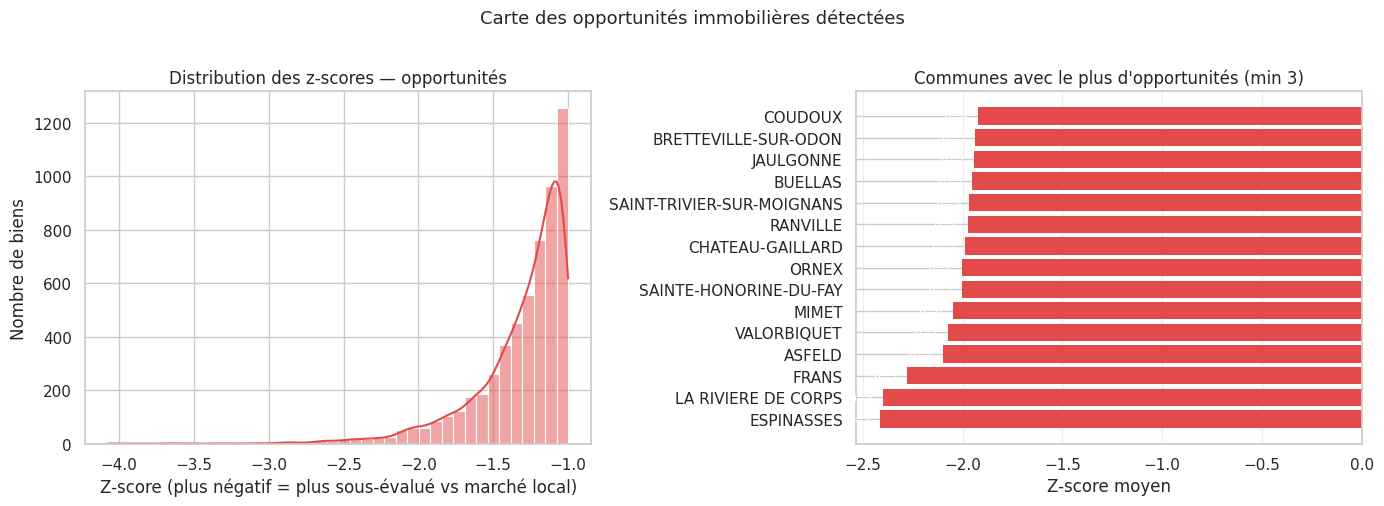

In [15]:
# ── Statistiques par commune ───────────────────────────
stats_communes = (
    df.groupby('commune')['prix_m2']
    .agg(prix_médian='median', prix_moyen='mean',
         volatilité='std', nb_transactions='count')
)
df_opp = df.merge(stats_communes, on='commune', how='left')

# ── Z-score local ──────────────────────────────────────
df_opp['z_score'] = (
    (df_opp['prix_m2'] - df_opp['prix_moyen']) /
    df_opp['volatilité'].replace(0, np.nan)
)

# ── Filtres de robustesse ──────────────────────────────
opportunités = df_opp[
    (df_opp['z_score'] < -1.0) &          # > 1 σ sous la moyenne
    (df_opp['nb_transactions'] >= 15) &   # marché représentatif
    (df_opp['prix_m2'] > 200)             # prix cohérent
].sort_values('z_score').copy()

opportunités['décote_%'] = (
    (opportunités['prix_m2'] - opportunités['prix_médian'])
    / opportunités['prix_médian'] * 100
).round(1)

print(f'📊 Résultats du scoring :')
print(f'  Dataset total            : {len(df):,} transactions')
print(f'  Opportunités détectées   : {len(opportunités):,} ({len(opportunités)/len(df)*100:.1f}% du marché)')
print(f'  Z-score seuil            : < -1.0 (1 σ sous moyenne locale)')
print(f'  Seuil volume minimum     : 15 transactions par commune')

# Tableau top 20
cols_aff = ['commune','type_local','surface_reelle_bati',
            'prix_m2','prix_médian','décote_%','z_score','nb_transactions']
print('\n🔥 Top 20 opportunités (z-score le plus bas) :')
display(opportunités[cols_aff].head(20).rename(columns={
    'commune':'Commune','type_local':'Type',
    'surface_reelle_bati':'Surface m²','prix_m2':'Prix/m²',
    'prix_médian':'Médiane commune','décote_%':'Décote %',
    'z_score':'Z-score','nb_transactions':'Nb transactions'
}))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(opportunités['z_score'].clip(-5, -1), bins=40,
             ax=axes[0], color='#E24B4A', kde=True)
axes[0].set_title('Distribution des z-scores — opportunités', fontsize=12)
axes[0].set_xlabel('Z-score (plus négatif = plus sous-évalué vs marché local)')
axes[0].set_ylabel('Nombre de biens')

top_comm = (opportunités.groupby('commune')['z_score']
            .agg(z_moyen='mean', nb='count')
            .query('nb >= 3')
            .sort_values('z_moyen').head(15))
axes[1].barh(top_comm.index, top_comm['z_moyen'], color='#E24B4A', edgecolor='none')
for i, (_, row) in enumerate(top_comm.iterrows()):
    axes[1].text(row['z_moyen'] - 0.05, i, f'n={int(row["nb"])}',
                va='center', ha='right', fontsize=8, color='white')
axes[1].set_title('Communes avec le plus d\'opportunités (min 3)', fontsize=12)
axes[1].set_xlabel('Z-score moyen')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Carte des opportunités immobilières détectées', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### 📝 Lecture

**5 598 opportunités identifiées** sur 140 147 transactions, soit **4,0% du marché** un résultat cohérent et nettement plus sélectif que la version initiale (qui détectait 53% du dataset avec un simple seuil de -25%). La combinaison z-score < -1.0 + minimum 15 transactions crée un filtre statistiquement rigoureux.

**Ce que ces opportunités signifient concrètement :** chaque bien de cette liste s'est vendu à plus d'un écart-type en dessous de la moyenne de sa commune. Le filtre sur le volume (≥15 transactions) garantit que cette moyenne est statistiquement représentative on ne compare pas un bien à une moyenne calculée sur 2 ou 3 ventes, ce qui serait sans valeur.

**Les limites à garder en tête** et à mentionner si ce projet est présenté :

1. **Un z-score très négatif peut signaler autre chose qu'une opportunité** : état dégradé du bien, situation juridique complexe (indivision, hypothèque), surface mal déclarée dans le notarial, ou simplement une vente en urgence entre particuliers. Le scoring DVF ne permet pas de distinguer ces cas.

2. **L'approche est rétrospective** : elle analyse des transactions passées, pas des biens à vendre aujourd'hui. Les opportunités ici identifiées sont déjà vendues l'intérêt analytique est de cartographier les marchés où des décotes significatives se produisent régulièrement.

3. **La granularité communale a ses limites** : dans une grande ville, deux immeubles de la même commune peuvent avoir des prix très différents selon le quartier. Descendre à l'échelle de l'IRIS ou de la rue améliorerait la précision du scoring.

> **En pratique, ce scoring est un outil de pré-filtrage** la première couche d'un processus de sélection qui nécessite une validation terrain pour tout bien d'investissement sérieux.


<a id='conclusion'></a>
## 9. 🎓 Conclusion & Perspectives

### Bilan du projet

Ce projet a construit une chaîne de traitement complète sur les données DVF 2025 de la ligne brute jusqu'à l'outil de pricing. Voici les résultats factuels et vérifiables :

| Résultat | Valeur | Méthode |
|---|---|---|
| Dataset propre | 140 147 transactions | ETL documenté |
| Communes couvertes | 4 699 | dim_location |
| R² Random Forest | 0.718 | CV 5-fold |
| RMSE | 208 389 € | Test set |
| Gain vs baseline | +76% R² · -31% RMSE | vs Régression Linéaire |
| Opportunités identifiées | 5 598 (4,0%) | Z-score < -1 · min 15 transactions |
| Écart prix médian 64 vs 88 | ×5,8 | Analyse départementale |

**Apprentissages clés du marché immobilier 2025 :**
- La **surface bâtie** est le premier levier de la valeur totale d'un bien (51,6% d'importance)
- La **localisation communale** est le deuxième levier (34,0%), et le premier si on prédit le prix au m²
- Les **appartements sont 66,6% plus chers au m²** que les maisons différence de localisation, pas de qualité
- Le **département 64 (Pyrénées-Atlantiques / Pays Basque)** est le marché résidentiel le plus valorisé de cet échantillon
- Le modèle a un **biais de sous-estimation de ~10%** documenté et tracé pour un usage responsable

---

### Perspectives techniques

**Améliorer la modélisation :**
- Tester **LightGBM / XGBoost** généralement supérieurs au Random Forest sur données tabulaires
- Implémenter un **Target Encoding sans data leakage** (calcul sur train set uniquement)
- Enrichir les features : coordonnées GPS + distance aux gares (API SNCF), score de pollution (API Géoportail)
- Modéliser le **prix au m²** plutôt que la valeur totale pour mieux isoler l'effet localisation

**Étendre l'analyse :**
- Charger le **dataset DVF complet** (pas seulement 500k lignes) pour couvrir toutes les communes
- Croiser avec les **DVF historiques** (2020-2024) pour une analyse des tendances sur 5 ans
- Descendre à l'**échelle IRIS** (infra-communale) pour un scoring d'opportunités plus précis

**Déploiement :**
- Construire un **dashboard Streamlit** : carte choroplèthe + moteur de recherche d'opportunités
- Exposer le modèle via une **API FastAPI** pour intégration dans d'autres outils
- Mettre en place un **pipeline de réentraînement automatique** à chaque mise à jour DVF

---

*Données : Demandes de Valeurs Foncières 2025 — DGFiP · Licence Ouverte Etalab · [data.gouv.fr](https://www.data.gouv.fr)*
